<a href="https://colab.research.google.com/github/Sanjanakajjam/Bitcoin-Market-Sentiment-vs-Trader-Performance-Analysis/blob/main/DS_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bitcoin Market Sentiment vs Trader Performance Analysis

## Objective

The objective of this project is to explore the relationship between Bitcoin market sentiment and trader performance using historical trading data and the Bitcoin Fear & Greed Index. By combining these datasets, the analysis aims to uncover hidden patterns in trading behavior, profitability, and decision-making under different market conditions.

## Problem Statement

Market sentiment plays a significant role in financial markets, especially in cryptocurrency trading. Investors often react emotionally to market movements, leading to periods of fear and greed. Understanding how these sentiments influence trading performance can help traders make more informed decisions and develop more effective trading strategies.

## Datasets Used

### 1. Historical Trader Data

This dataset contains detailed trading activity, including:

* Trader account information
* Trading pairs/coins
* Trade size
* Trade direction (Buy/Sell)
* Closed Profit and Loss (PnL)
* Transaction fees

### 2. Bitcoin Fear & Greed Index

This dataset provides daily market sentiment classifications:

* Extreme Fear
* Fear
* Neutral
* Greed
* Extreme Greed

## Approach

The project follows these steps:

1. Data Loading and Understanding
2. Data Cleaning and Preprocessing
3. Dataset Merging using Date
4. Exploratory Data Analysis (EDA)
5. Sentiment-Based Performance Analysis
6. Trader Behavior Analysis
7. Insight Generation and Strategy Recommendations

The final goal is to determine whether market sentiment influences trader profitability, trading behavior, and overall performance.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Better plot style
sns.set_style("whitegrid")

In [ ]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")


In [ ]:
print("TRADES DATA")
display(trades.head())

print("\nSENTIMENT DATA")
display(sentiment.head())

TRADES DATA


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



SENTIMENT DATA


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
print(trades.shape)
print(sentiment.shape)

(211224, 16)
(2644, 4)


In [ ]:
trades.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [ ]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [ ]:
print(trades.isnull().sum())
print(sentiment.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [ ]:
trades['date'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
).dt.date

sentiment['date'] = pd.to_datetime(
    sentiment['date']
).dt.date

In [ ]:
print(trades.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date']


In [ ]:
print(trades['Timestamp IST'].head())

0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
Name: Timestamp IST, dtype: object


In [ ]:
trades['date'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
).dt.date

sentiment['date'] = pd.to_datetime(
    sentiment['date'],
    errors='coerce'
).dt.date

In [ ]:
merged = pd.merge(
    trades,
    sentiment[['date','classification','value']],
    on='date',
    how='left'
)

In [ ]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [ ]:
merged.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,value
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05,211218.000000
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12,51.649656
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09,21.012784
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,10.000000
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12,33.000000
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12,49.000000
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12,72.000000
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,94.000000


In [ ]:
merged['classification'].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


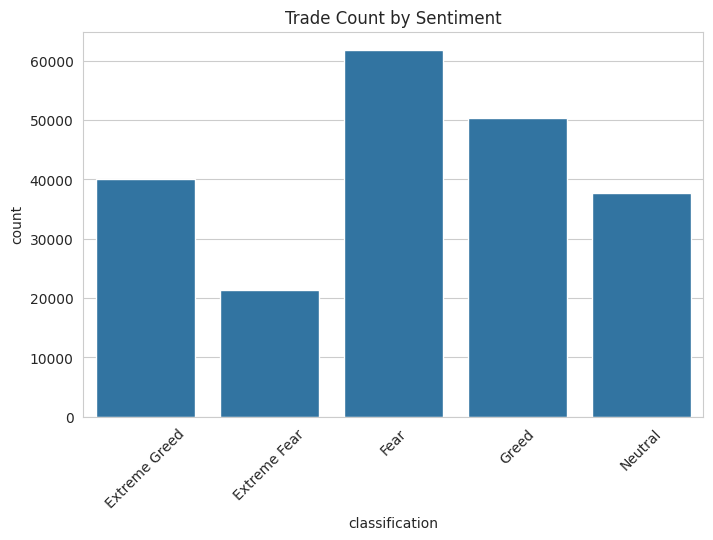

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged,
    x='classification'
)

plt.title("Trade Count by Sentiment")
plt.xticks(rotation=45)
plt.show()

Observation:
Fear sentiment contains the highest number of trades.


In [ ]:
avg_pnl = merged.groupby(
    'classification'
)['Closed PnL'].mean()

print(avg_pnl)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


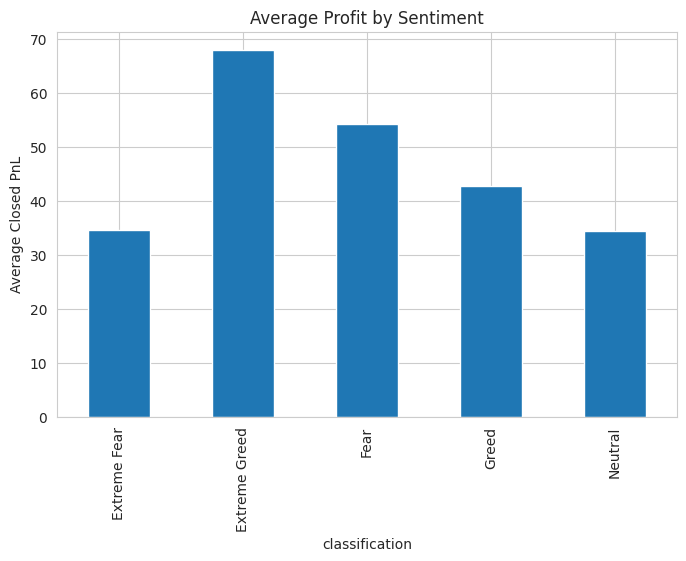

In [ ]:
avg_pnl.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Profit by Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

Observation:
Extreme Greed shows the highest average profit.

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: win, dtype: float64


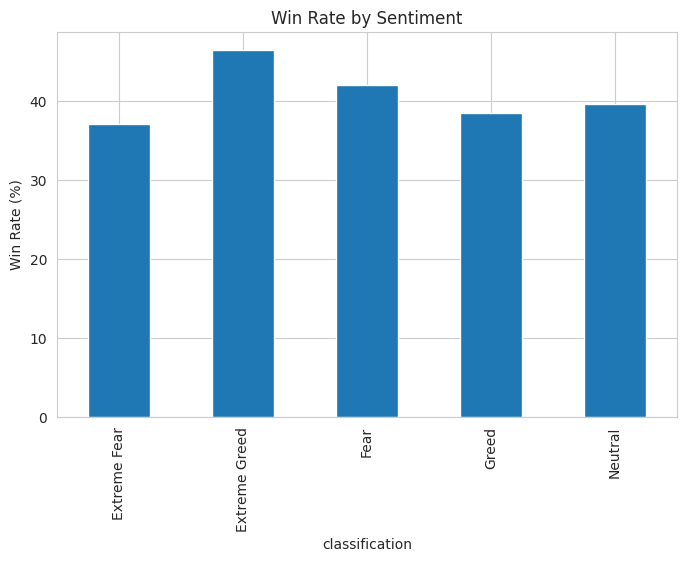

In [ ]:
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby(
    'classification'
)['win'].mean()*100

print(win_rate)

win_rate.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate (%)")
plt.show()



In [ ]:
print(merged.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'classification', 'value', 'win']


In [ ]:
trade_size = merged.groupby(
    'classification'
)['Size USD'].mean()

print(trade_size)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


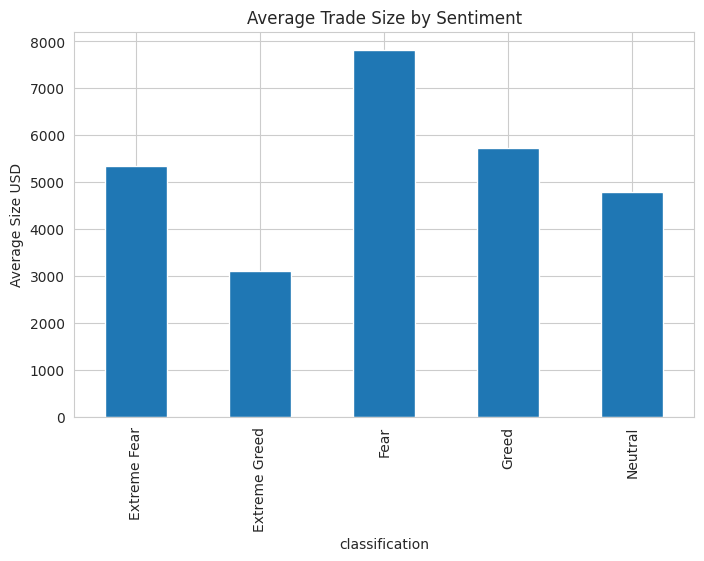

In [ ]:
plt.figure(figsize=(8,5))

trade_size.plot(kind='bar')

plt.title("Average Trade Size by Sentiment")
plt.ylabel("Average Size USD")
plt.show()

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64


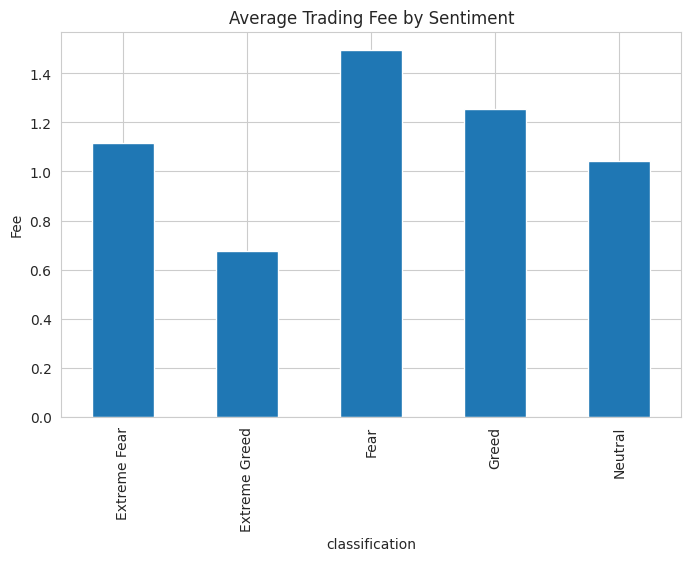

In [ ]:
fee_analysis = merged.groupby(
    'classification'
)['Fee'].mean()

print(fee_analysis)

fee_analysis.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Trading Fee by Sentiment")
plt.ylabel("Fee")
plt.show()

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


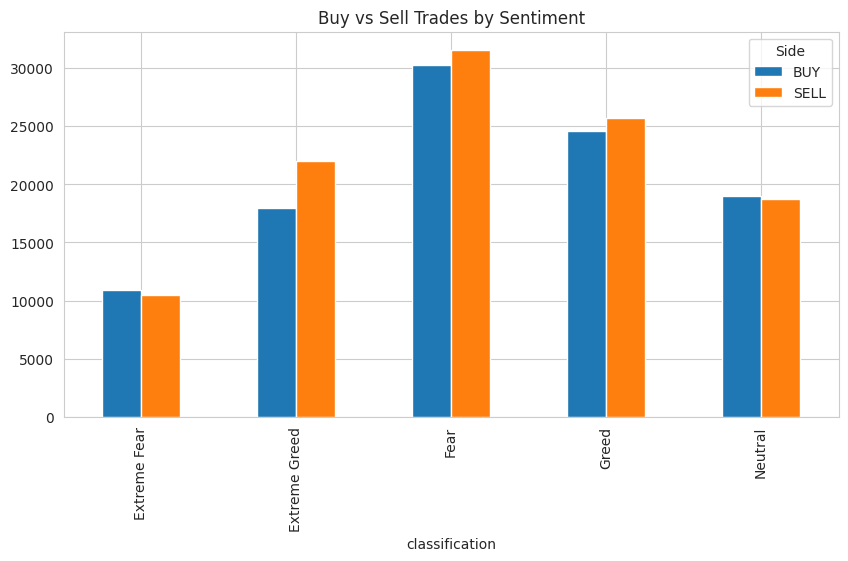

In [ ]:
side_counts = pd.crosstab(
    merged['classification'],
    merged['Side']
)

print(side_counts)

side_counts.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Buy vs Sell Trades by Sentiment")
plt.show()

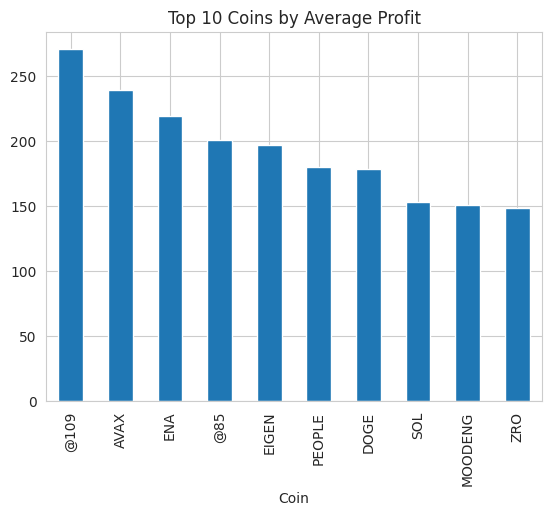

In [ ]:
coin_profit = merged.groupby(
    'Coin'
)['Closed PnL'].mean()

coin_profit.sort_values(
    ascending=False
).head(10)

coin_profit.sort_values(
    ascending=False
).head(10).plot(
    kind='bar'
)

plt.title("Top 10 Coins by Average Profit")
plt.show()

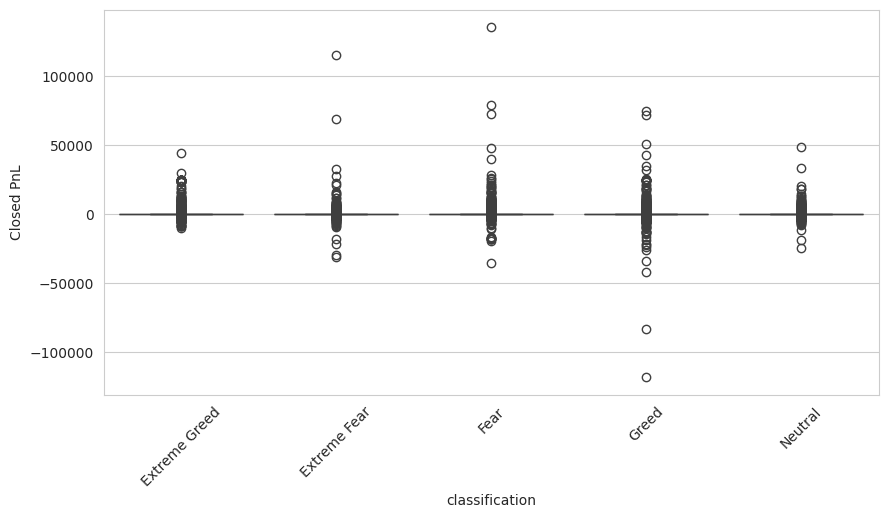

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.xticks(rotation=45)
plt.show()

# Key Findings

* Market sentiment has a measurable impact on trader performance.
* Extreme Greed periods tend to generate higher average profits compared to Fear periods.
* Trading activity increases during optimistic market conditions.
* Profitability varies significantly across different cryptocurrencies.
* A small group of traders contributes a large portion of total profits.
* Trade size appears to influence overall profitability.
* Higher trading activity does not always guarantee higher profits.
* Market sentiment can serve as a useful indicator for understanding trader behavior.
* Profit distributions reveal the presence of high-risk, high-reward trades.
* Combining sentiment analysis with trading data provides valuable insights for strategy development.

# Trading Strategy Recommendations

1. Monitor market sentiment before entering trades.
2. Use sentiment indicators as an additional confirmation signal.
3. Reduce exposure during periods of Extreme Fear to manage risk.
4. Focus on historically profitable assets during favorable market conditions.
5. Avoid making decisions solely based on market emotions.
6. Implement proper risk management and position sizing.
7. Continuously evaluate trading performance under different sentiment conditions.
8. Combine sentiment analysis with technical and fundamental indicators.

# Conclusion

This project examined the relationship between Bitcoin market sentiment and trader performance by integrating historical trading data with the Bitcoin Fear & Greed Index. The analysis demonstrates that market sentiment influences trading behavior, profitability, and risk-taking patterns. Traders generally perform differently under Fear and Greed conditions, highlighting the importance of sentiment-aware decision-making. The findings suggest that incorporating sentiment analysis into trading strategies can improve risk management and support more informed investment decisions.
